# OpenStreetMap overview

東京都新宿区を対象に、OSM から境界・カフェ・駅・徒歩道路網を読み込んで簡単に概観するノートです。

In [1]:
# 必要なら一度だけ実行
%pip install osmnx geopandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import matplotlib.pyplot as plt
import osmnx as ox
import pandas as pd
import seaborn as sns
from IPython.display import display
from osmnx._errors import InsufficientResponseError

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 20)
sns.set_theme(style="whitegrid")
ox.settings.use_cache = True
ox.settings.log_console = False

In [3]:
import osmnx as ox
import geopandas as gpd

ox.settings.use_cache = True
ox.settings.log_console = True

# 1. まずは place を明示的に指定
query = {
    "city": "Shinjuku-ku",
    "state": "Tokyo",
    "country": "Japan",
}

# 2. 境界の確認
shinjuku = ox.geocode_to_gdf(query, which_result=1)

print(shinjuku[["display_name", "class", "type"]])
print(shinjuku.geometry.iloc[0].geom_type)

# 3. place から直接カフェ取得
tags = {"amenity": "cafe"}
cafes = ox.features_from_place(query, tags)

print(f"取得件数: {len(cafes)}")
print(cafes[["name", "amenity"]].head())

                       display_name     class            type
0  Shinjuku, Tokyo, 160-8484, Japan  boundary  administrative
Polygon
取得件数: 353
                            name amenity
element id                              
node    277836382        スターバックス    cafe
        428013491   CAT'S CRADLE    cafe
        428022820            ビレン    cafe
        691449457         カナルカフェ    cafe
        1075317953     カフェ・ベローチェ    cafe


In [4]:
cafes["geometry"] = cafes.geometry.representative_point()
cafes = cafes.reset_index(drop=True)
cafes = cafes.drop(columns=[c for c in ["element", "id"] if c in cafes.columns])
cafes


,geometry,addr:block_number,addr:city,addr:housenumber,addr:province,addr:quarter,amenity,branch,brand,brand:en,brand:ja,brand:wikidata,brand:wikipedia,cuisine,drive_through,internet_access,level,name,name:en,name:ja,name:ja_rm,official_name,official_name:en,official_name:ja,opening_hours,...,alt_name,reservation,brand:zh,brand:zh-Latn-pinyin,name:ja-Kana,payment:cards,payment:debit_cards,payment:alipay,payment:american_express,payment:apple_pay,payment:contactless,payment:diners_club,payment:google_pay,payment:jcb,payment:mastercard,payment:mastercard_contactless,payment:notes,payment:visa,payment:wechat,stroller,website:menu,building,roof:shape,type,room
0,POINT (139.74245 35.70185),2,新宿区,1,東京都,揚場町,cafe,飯田橋軽子坂店,スターバックス,Starbucks,スターバックス,Q37158,ja:スターバックス,coffee_shop,no,wlan,0,スターバックス,Starbucks,スターバックス,Sutābakkusu,スターバックスコーヒー,Starbucks Coffee,スターバックスコーヒー,"Mo-Sa 07:00-22:00; PH,Su 08:00-21:00",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,POINT (139.72227 35.70861),NaN,NaN,NaN,NaN,NaN,cafe,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CAT'S CRADLE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,POINT (139.72256 35.7086),NaN,NaN,NaN,NaN,NaN,cafe,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ビレン,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,POINT (139.74281 35.70029),NaN,NaN,NaN,NaN,NaN,cafe,NaN,NaN,NaN,NaN,NaN,NaN,italian,NaN,NaN,NaN,カナルカフェ,Canal Cafe,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,POINT (139.73937 35.7018),1,新宿区,1,東京都,NaN,cafe,神楽坂店,カフェ・ベローチェ,CAFFÈ VELOCE,カフェ・ベローチェ,Q11294597,NaN,coffee_shop,NaN,NaN,0,カフェ・ベローチェ,CAFE VELOCE,カフェ・ベローチェ,Kafe Berōche,NaN,NaN,NaN,Mo-Su 07:00-23:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
348,POINT (139.70902 35.69611),NaN,NaN,NaN,NaN,NaN,cafe,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Artnia Cafe,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,yes,dome,NaN,NaN
349,POINT (139.7083 35.68558),NaN,NaN,NaN,NaN,NaN,cafe,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,翔天亭,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,yes,NaN,NaN,NaN
350,POINT (139.69979 35.72213),NaN,NaN,NaN,NaN,NaN,cafe,NaN,NaN,NaN,NaN,NaN,NaN,coffee_shop;brunch,NaN,NaN,NaN,POLANO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,yes,NaN,NaN,NaN
351,POINT (139.72124 35.70953),NaN,NaN,NaN,NaN,NaN,cafe,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Uni Shop & Café 125,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,retail,NaN,NaN,NaN


In [5]:
# name を持っている行だけ残す
cafes_filtered = cafes.copy()
has_name = cafes_filtered.get("name", pd.Series(index=cafes_filtered.index)).notna()
cafes_filtered = cafes_filtered[has_name].copy()
print(f"filtered rows: {len(cafes_filtered):,} / {len(cafes):,}")
cafes_filtered


filtered rows: 331 / 353


,geometry,addr:block_number,addr:city,addr:housenumber,addr:province,addr:quarter,amenity,branch,brand,brand:en,brand:ja,brand:wikidata,brand:wikipedia,cuisine,drive_through,internet_access,level,name,name:en,name:ja,name:ja_rm,official_name,official_name:en,official_name:ja,opening_hours,...,alt_name,reservation,brand:zh,brand:zh-Latn-pinyin,name:ja-Kana,payment:cards,payment:debit_cards,payment:alipay,payment:american_express,payment:apple_pay,payment:contactless,payment:diners_club,payment:google_pay,payment:jcb,payment:mastercard,payment:mastercard_contactless,payment:notes,payment:visa,payment:wechat,stroller,website:menu,building,roof:shape,type,room
0,POINT (139.74245 35.70185),2,新宿区,1,東京都,揚場町,cafe,飯田橋軽子坂店,スターバックス,Starbucks,スターバックス,Q37158,ja:スターバックス,coffee_shop,no,wlan,0,スターバックス,Starbucks,スターバックス,Sutābakkusu,スターバックスコーヒー,Starbucks Coffee,スターバックスコーヒー,"Mo-Sa 07:00-22:00; PH,Su 08:00-21:00",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,POINT (139.72227 35.70861),NaN,NaN,NaN,NaN,NaN,cafe,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CAT'S CRADLE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,POINT (139.72256 35.7086),NaN,NaN,NaN,NaN,NaN,cafe,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ビレン,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,POINT (139.74281 35.70029),NaN,NaN,NaN,NaN,NaN,cafe,NaN,NaN,NaN,NaN,NaN,NaN,italian,NaN,NaN,NaN,カナルカフェ,Canal Cafe,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,POINT (139.73937 35.7018),1,新宿区,1,東京都,NaN,cafe,神楽坂店,カフェ・ベローチェ,CAFFÈ VELOCE,カフェ・ベローチェ,Q11294597,NaN,coffee_shop,NaN,NaN,0,カフェ・ベローチェ,CAFE VELOCE,カフェ・ベローチェ,Kafe Berōche,NaN,NaN,NaN,Mo-Su 07:00-23:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
348,POINT (139.70902 35.69611),NaN,NaN,NaN,NaN,NaN,cafe,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Artnia Cafe,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,yes,dome,NaN,NaN
349,POINT (139.7083 35.68558),NaN,NaN,NaN,NaN,NaN,cafe,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,翔天亭,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,yes,NaN,NaN,NaN
350,POINT (139.69979 35.72213),NaN,NaN,NaN,NaN,NaN,cafe,NaN,NaN,NaN,NaN,NaN,NaN,coffee_shop;brunch,NaN,NaN,NaN,POLANO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,yes,NaN,NaN,NaN
351,POINT (139.72124 35.70953),NaN,NaN,NaN,NaN,NaN,cafe,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Uni Shop & Café 125,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,retail,NaN,NaN,NaN


In [9]:
%pip install contextily

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.9/35.9 MB 28.2 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9/9 [contextily]9 [rasterio]
Note: you may need to restart the kernel to use updated packages.


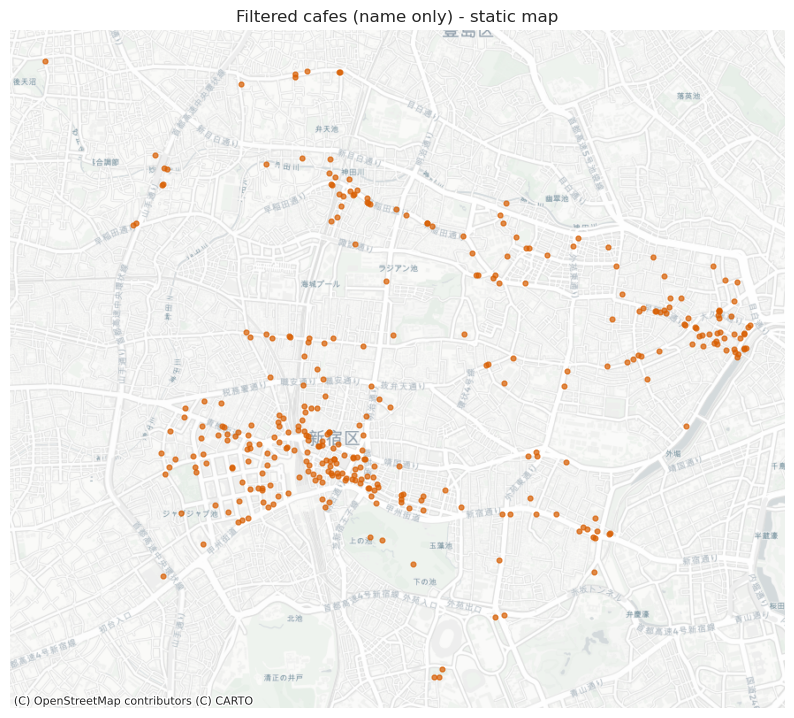

In [10]:
# 静的地図（contextily）
# %pip install contextily
import contextily as ctx

static_df = cafes_filtered.copy()
static_df = static_df.to_crs(3857)

fig, ax = plt.subplots(figsize=(10, 10))
static_df.plot(ax=ax, color='#D95F02', markersize=12, alpha=0.7)

# タイル追加（CartoDB Positron）
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
ax.set_axis_off()
ax.set_title('Filtered cafes (name only) - static map')
plt.show()


In [11]:
# フィルタ後データを Parquet で保存
import geopandas as gpd
from pathlib import Path

output_path = Path('./data/cafes_filtered.parquet')
output_path.parent.mkdir(parents=True, exist_ok=True)

# Parquet 書き込み（GeoDataFrame なら geometry を含めて保存）
cafes_filtered.to_parquet(output_path, index=False)
print(f'written: {output_path.resolve()}')


written: /home/kohei/WorkSpace/blog/04.anaba_cafe/data/cafes_filtered.parquet
